Loading data...
  Rows       : 234
  Columns    : 124
  Date range : 2005-01-01 to 2024-06-01
  GDP obs    : 77 quarterly observations
  Param grid : 24 combinations (tunable) + 3 fixed hyperparameters

Running rolling-origin XGBoost evaluation...
  Train start     : 2005-01-01
  Test window     : 2020-03-01 to 2024-06-01
  Vintages        : [-2, -1, 0]
  Lag depth       : 4 monthly lags per predictor
  Param grid      : 24 combinations (exhaustive)
  Param selection : fixed holdout (8 quarters)
  Scaling         : not applied (trees are scale-invariant)
  Imputation      : training-mean fill (same as Ridge/Lasso)

  [2020-03-01]  depth=3  n_est=50  lr=0.05  lambda=1.0  n_train=59  features=610
  [2020-06-01]  depth=2  n_est=150  lr=0.05  lambda=5.0  n_train=60  features=610
  [2020-09-01]  depth=2  n_est=150  lr=0.10  lambda=1.0  n_train=61  features=610
  [2020-12-01]  depth=2  n_est=150  lr=0.05  lambda=1.0  n_train=62  features=610
  [2021-03-01]  depth=2  n_est=150  lr=0.10  lambd

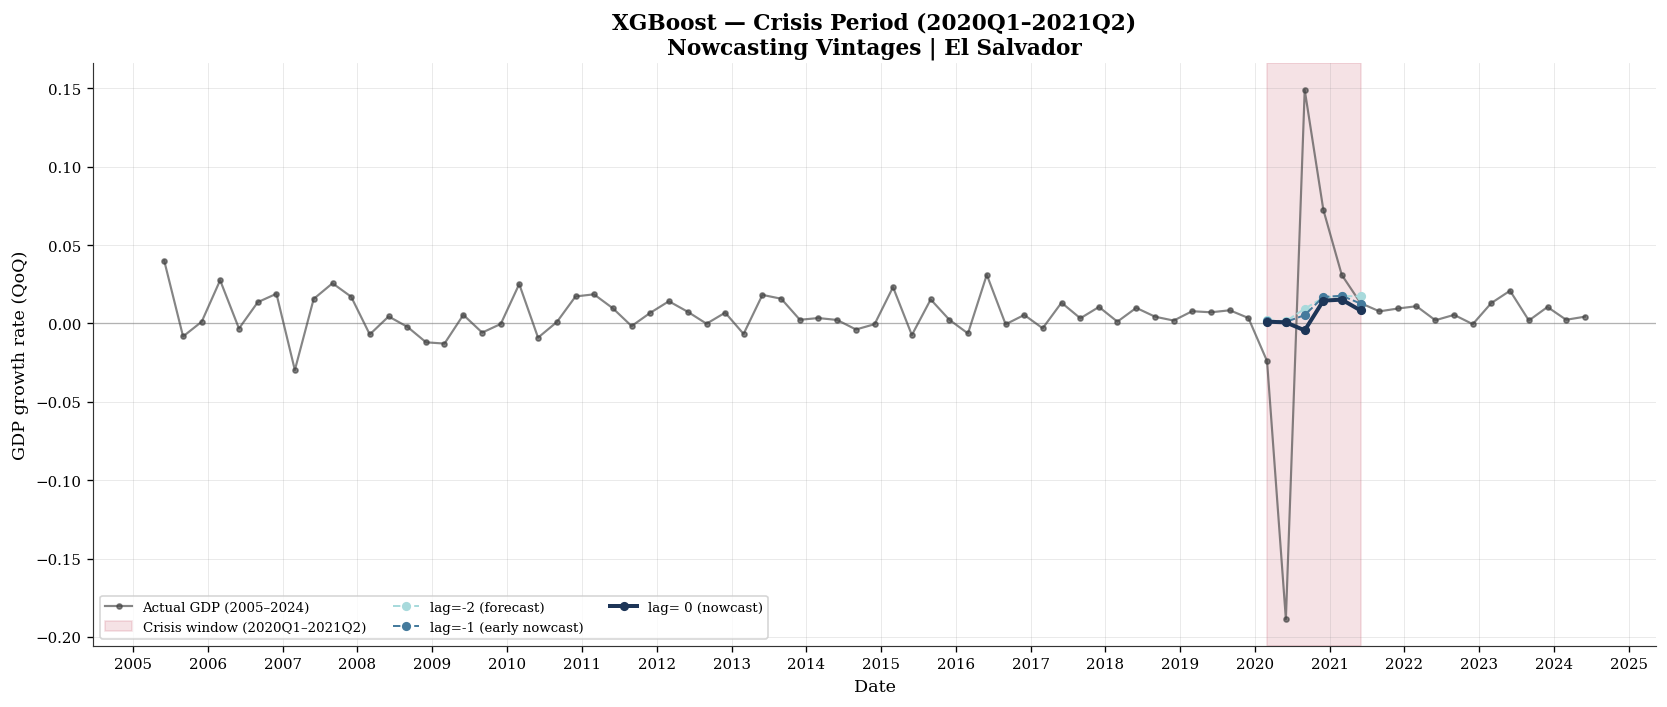

Saved: xgboost_plot_crisis.png


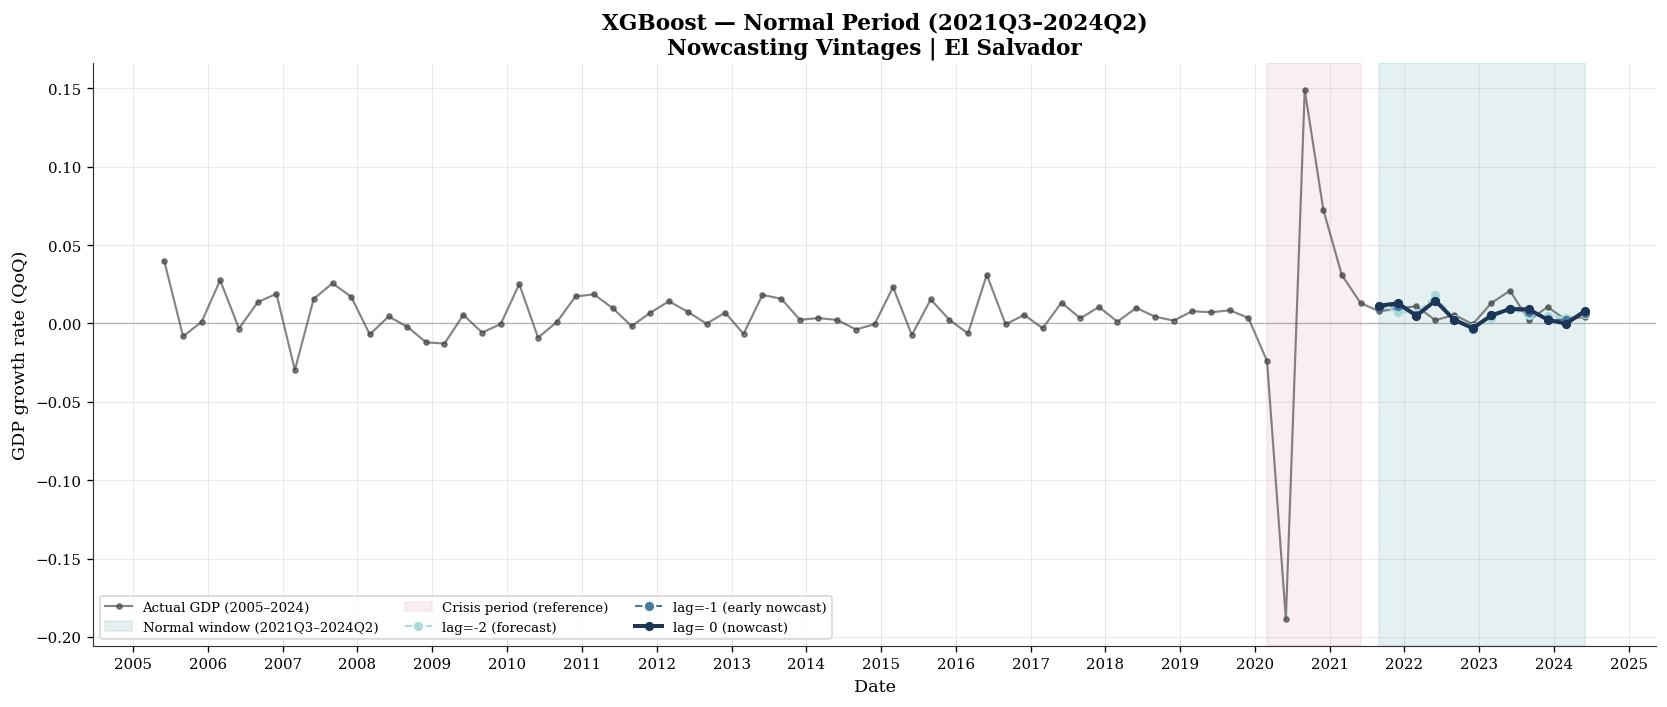

Saved: xgboost_plot_normal.png


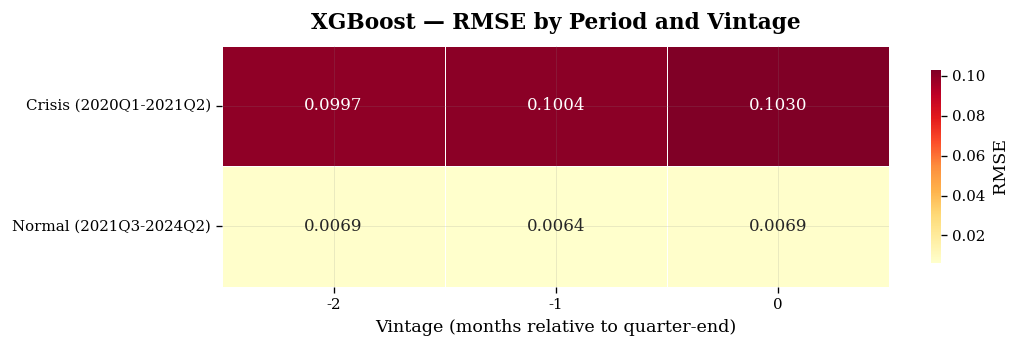

Saved: xgboost_plot_heatmap.png


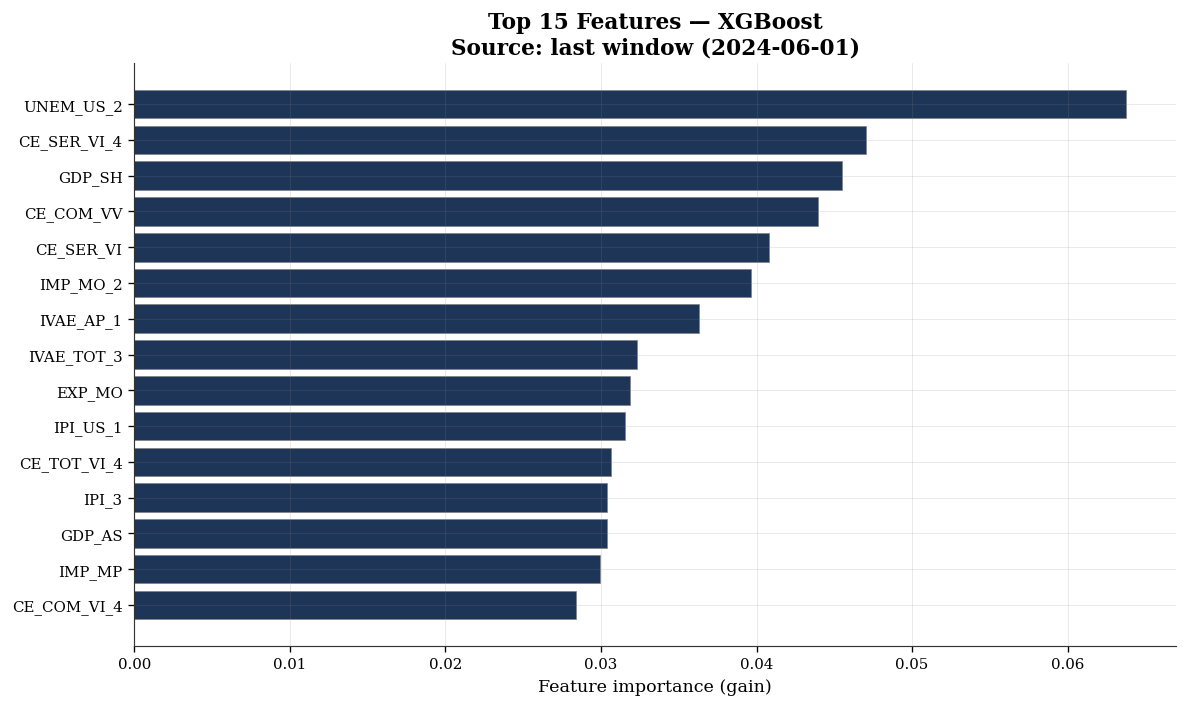

Saved: xgboost_plot_features.png


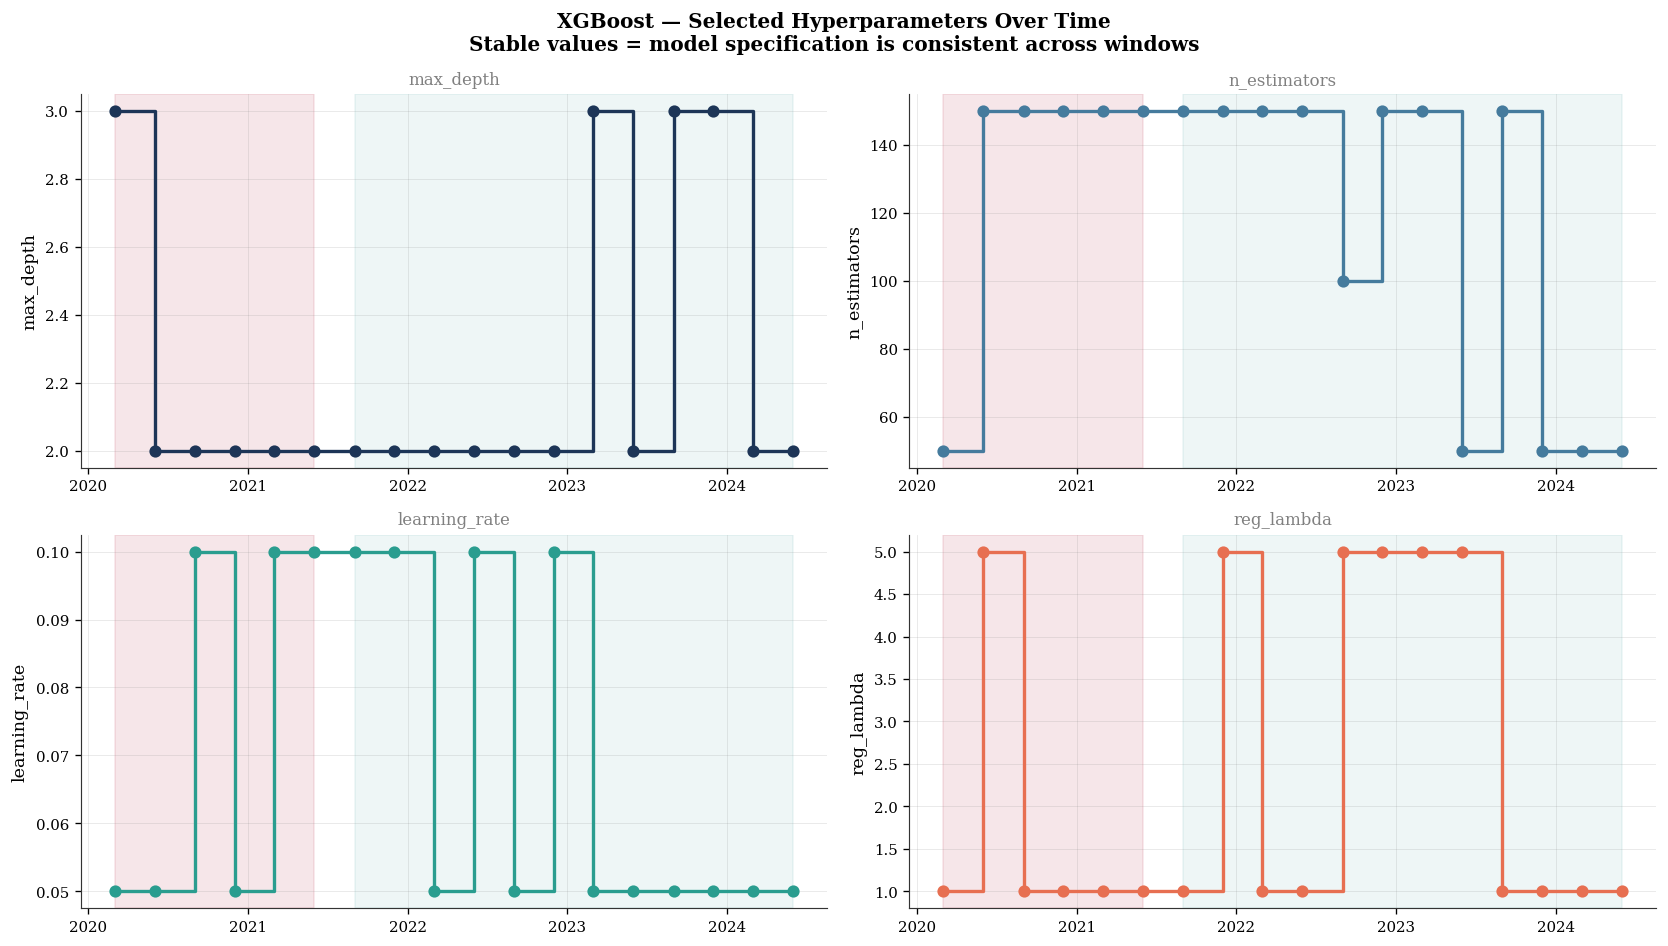

Saved: xgboost_plot_params.png

XGBOOST NOWCASTING COMPLETE
Output : /Users/gabrielaaquino/Desktop/ESA-gdp-nowcasting/Models/results/xgboost


In [1]:
# =============================================================================
# XGBoost.py
# XGBoost nowcasting pipeline for El Salvador GDP.
# Hyperparameters selected via fixed holdout (last 8 quarters of training),
# identical protocol to Ridge and Lasso for direct comparability.
#
# Primary benchmark is ARMA (see ARMA.ipynb). Cross-model comparison is
# done in a separate comparison script that loads all per-model CSVs.
#
# Author : Gabriela Aquino
# =============================================================================
#
# WHY XGBOOST DIFFERS FROM RIDGE AND LASSO
# -----------------------------------------
# XGBoost is a gradient-boosted tree ensemble. Unlike Ridge/Lasso, it:
#   - Captures non-linear relationships and feature interactions
#   - Does NOT require feature scaling (trees are scale-invariant)
#   - Has multiple interacting hyperparameters
#
# NOTE ON MEAN-FILL IMPUTATION (methodological choice):
# XGBoost natively handles NaN via a "default direction" learned per split.
# In principle, passing NaN directly would let XGBoost exploit this.
# HOWEVER, we deliberately mean-fill here to keep the data-processing
# protocol IDENTICAL to Ridge/Lasso. Cross-model comparability is more
# valuable for the thesis than a small potential gain from NaN handling.
# A sensitivity analysis (NaN vs mean-fill) could be added as an appendix.
#
# CRITICAL: with n ~ 55-76 observations and ~615 features, XGBoost is
# strongly constrained by:
#   - Shallow trees (max_depth <= 3)
#   - Moderate n_estimators (50 to 150)
#   - L2 regularisation (reg_lambda >= 1)
#   - No early stopping (would complicate the protocol vs Ridge/Lasso)
# =============================================================================
#
# TUNABLE PARAMETERS (safe to modify — see Section 1):
#   N_LAGS_FEATURES     : monthly lags per predictor (baseline = 4)
#   XGB_PARAM_GRID      : hyperparameter grid
#   N_HOLDOUT_QUARTERS  : size of fixed holdout for tuning (default 8)
#
# SHARED CONFIG (do not modify — comes from nowcast_utils.py):
#   LAGS, TRAIN_START, TEST_START, TEST_END,
#   CRISIS_START/END, NORMAL_START/END, etc.
# =============================================================================

import sys
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

from xgboost import XGBRegressor

# Selective warning filters.
# We WANT to see XGBoost warnings and warnings from gen_lagged_data.
# Silence only noisy FutureWarning and UserWarning from third parties.
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# =============================================================================
# 0. PATHS AND SHARED-CONFIG IMPORT
# =============================================================================
BASE_DIR  = Path.home() / "Desktop" / "ESA-gdp-nowcasting"
DATA_DIR  = BASE_DIR / "Data"
MODEL_DIR = BASE_DIR / "Models"
OUT_DIR   = MODEL_DIR / "results" / "xgboost"
OUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(MODEL_DIR))

from nowcast_utils import (
    LAGS, TARGET_VARIABLE,
    TRAIN_START, TEST_START, TEST_END,
    CRISIS_START, CRISIS_END,
    NORMAL_START, NORMAL_END,
    RANDOM_SEED,
    gen_lagged_data, flatten_data, mean_fill_dataset,
    classify_crisis_periods,
    rmse, mae,
)

PATH_DATA = DATA_DIR / "data_tf.csv"
PATH_META = DATA_DIR / "meta_data_v2.csv"
for p in [PATH_DATA, PATH_META]:
    if not p.exists():
        raise FileNotFoundError(f"\n  File not found: {p}")

# =============================================================================
# 1. TUNABLE PARAMETERS (XGBoost-specific)
# =============================================================================
# Number of monthly lags per predictor. MUST match Ridge and Lasso.
N_LAGS_FEATURES: int = 4

# Fixed holdout: last N quarters of training used for hyperparameter selection.
# MUST match Ridge and Lasso for comparability.
N_HOLDOUT_QUARTERS: int = 8

# XGBoost hyperparameter grid (adelgazado para n pequeño).
# max_depth       : tree depth. 2-3 = shallow (low variance). Do NOT use > 3.
# n_estimators    : number of boosting rounds. Moderate range given n <= 76.
# learning_rate   : step size shrinkage.
# reg_lambda      : L2 regularisation on leaf weights.
# subsample       : fixed at 0.8 (row sampling, small n).
# colsample_bytree: fixed at 0.8 (column sampling, p >> n).
# min_child_weight: fixed at 5 (conservative for small n).
XGB_PARAM_GRID = {
    "max_depth":        [2, 3],
    "n_estimators":     [50, 100, 150],
    "learning_rate":    [0.05, 0.10],
    "reg_lambda":       [1.0, 5.0],
    # Fixed parameters (not in grid, applied to all candidates)
}
XGB_FIXED_PARAMS = {
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "objective":        "reg:squarederror",
    "eval_metric":      "rmse",
    "random_state":     RANDOM_SEED,
    "n_jobs":           -1,
    "verbosity":        0,
}

np.random.seed(RANDOM_SEED)

# =============================================================================
# 2. LOAD DATA
# =============================================================================
print("Loading data...")
data     = pd.read_csv(PATH_DATA, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
metadata = pd.read_csv(PATH_META)

print(f"  Rows       : {data.shape[0]}")
print(f"  Columns    : {data.shape[1]}")
print(f"  Date range : {data['date'].min().date()} to {data['date'].max().date()}")
print(f"  GDP obs    : {data[TARGET_VARIABLE].notna().sum()} quarterly observations")

# Build list of all grid combinations
param_keys   = list(XGB_PARAM_GRID.keys())
param_values = list(XGB_PARAM_GRID.values())
all_combos   = list(itertools.product(*param_values))
print(f"  Param grid : {len(all_combos)} combinations (tunable) "
      f"+ {len(XGB_FIXED_PARAMS) - 5} fixed hyperparameters")

test_dates = pd.date_range(TEST_START, TEST_END, freq="3MS").strftime("%Y-%m-%d").tolist()

# =============================================================================
# 3. ROLLING-ORIGIN EVALUATION
# =============================================================================
print("\nRunning rolling-origin XGBoost evaluation...")
print(f"  Train start     : {TRAIN_START}")
print(f"  Test window     : {TEST_START} to {TEST_END}")
print(f"  Vintages        : {LAGS}")
print(f"  Lag depth       : {N_LAGS_FEATURES} monthly lags per predictor")
print(f"  Param grid      : {len(all_combos)} combinations (exhaustive)")
print(f"  Param selection : fixed holdout ({N_HOLDOUT_QUARTERS} quarters)")
print(f"  Scaling         : not applied (trees are scale-invariant)")
print(f"  Imputation      : training-mean fill (same as Ridge/Lasso)\n")

pred_dict                    = {lag: [] for lag in LAGS}
dates_out                    = []
actuals_out                  = []
best_params_out              = []
feature_importance_by_window = []   # list of (date, df) for post-hoc selection
train_cutoff_last            = None

for nowcast_date in test_dates:

    # --- Actual GDP value ----------------------------------------------------
    nowcast_dt  = pd.to_datetime(nowcast_date)
    actual_rows = data.loc[
        (data["date"] == nowcast_dt) & (~pd.isna(data[TARGET_VARIABLE])),
        TARGET_VARIABLE
    ]
    if actual_rows.empty:
        print(f"  [{nowcast_date}] No actual GDP - skipping.")
        for lag in LAGS:
            pred_dict[lag].append(np.nan)
        dates_out.append(nowcast_date)
        actuals_out.append(np.nan)
        best_params_out.append(None)
        continue

    dates_out.append(nowcast_date)
    actuals_out.append(float(actual_rows.values[0]))

    # --- Training window -----------------------------------------------------
    train_cutoff      = (nowcast_dt - pd.DateOffset(months=3)).strftime("%Y-%m-%d")
    train_cutoff_last = train_cutoff

    train_raw = data.loc[
        (data["date"] >= TRAIN_START) & (data["date"] <= train_cutoff)
    ].copy()

    n_q = train_raw[TARGET_VARIABLE].notna().sum()

    # --- Build feature matrix ------------------------------------------------
    # Mean-fill with training means (documented methodological choice to
    # preserve protocol identity with Ridge/Lasso, at the cost of XGBoost
    # not exploiting its native NaN handling).
    train_filled = mean_fill_dataset(training=train_raw, test=train_raw)
    train_flat   = flatten_data(train_filled, TARGET_VARIABLE, N_LAGS_FEATURES)
    train_flat   = (
        train_flat
        .loc[train_flat["date"].dt.month.isin([3, 6, 9, 12])]
        .dropna(axis=0, how="any")
        .reset_index(drop=True)
    )

    if len(train_flat) < N_HOLDOUT_QUARTERS + 5:
        print(f"  [{nowcast_date}] Only {len(train_flat)} rows - skipping.")
        for lag in LAGS:
            pred_dict[lag].append(np.nan)
        best_params_out.append(None)
        continue

    X_train = train_flat.drop(columns=["date", TARGET_VARIABLE])
    y_train = train_flat[TARGET_VARIABLE]

    # --- Hyperparameter selection via fixed holdout --------------------------
    # Protocol identical to ridge_final.py and lasso_final.py:
    #   inner-train = all quarters except last N_HOLDOUT_QUARTERS
    #   holdout     = last N_HOLDOUT_QUARTERS of the training window
    #
    # XGBoost does NOT need feature scaling — trees split on rank order,
    # not on absolute distances.
    X_inner = X_train.iloc[:-N_HOLDOUT_QUARTERS]
    y_inner = y_train.iloc[:-N_HOLDOUT_QUARTERS]
    X_hold  = X_train.iloc[-N_HOLDOUT_QUARTERS:]
    y_hold  = y_train.iloc[-N_HOLDOUT_QUARTERS:]

    # Grid search: find combination that minimises holdout RMSE
    best_params, best_rmse = None, np.inf
    for combo in all_combos:
        tunable = dict(zip(param_keys, combo))
        xgb_cv = XGBRegressor(**XGB_FIXED_PARAMS, **tunable)
        xgb_cv.fit(X_inner, y_inner)
        val_rmse = rmse(y_hold, xgb_cv.predict(X_hold))
        if val_rmse < best_rmse:
            best_rmse   = val_rmse
            best_params = tunable

    best_params_out.append(best_params)

    # --- Refit XGBoost on full training with best params --------------------
    final_xgb = XGBRegressor(**XGB_FIXED_PARAMS, **best_params)
    final_xgb.fit(X_train, y_train)

    # Feature importance from this window (gain = loss reduction)
    feature_importance_by_window.append((
        nowcast_date,
        pd.DataFrame({
            "feature":    X_train.columns,
            "importance": final_xgb.feature_importances_,
        }).sort_values("importance", ascending=False)
    ))

    # --- Diagnostics print ---------------------------------------------------
    print(f"  [{nowcast_date}]  "
          f"depth={best_params['max_depth']}  "
          f"n_est={best_params['n_estimators']}  "
          f"lr={best_params['learning_rate']:.2f}  "
          f"lambda={best_params['reg_lambda']:.1f}  "
          f"n_train={n_q}  features={X_train.shape[1]}")

    # --- Predict for each vintage -------------------------------------------
    for lag in LAGS:
        vintage_data = gen_lagged_data(metadata, data, nowcast_date, lag)
        vintage_data = mean_fill_dataset(training=train_raw, test=vintage_data)
        vintage_flat = flatten_data(vintage_data, TARGET_VARIABLE, N_LAGS_FEATURES)

        target_row = vintage_flat.loc[vintage_flat["date"] == nowcast_dt]
        if target_row.empty:
            pred_dict[lag].append(np.nan)
            continue

        X_test = (
            target_row
            .drop(columns=["date", TARGET_VARIABLE], errors="ignore")
            .reindex(columns=X_train.columns, fill_value=0.0)
        )

        pred_dict[lag].append(float(final_xgb.predict(X_test)[0]))

# =============================================================================
# 4. PERFORMANCE METRICS
# =============================================================================
# Period labels come from nowcast_utils (single source of truth)
period_labels = classify_crisis_periods(dates_out).tolist()

# --- Full test period --------------------------------------------------------
full_rows = []
for lag in LAGS:
    full_rows.append({
        "Vintage": lag,
        "RMSE":    round(rmse(actuals_out, pred_dict[lag]), 6),
        "MAE":     round(mae(actuals_out,  pred_dict[lag]), 6),
        "n":       sum(1 for v in pred_dict[lag] if not np.isnan(v)),
    })
perf_full = pd.DataFrame(full_rows)

# --- Stratified: Crisis / Normal --------------------------------------------
strat_rows = []
for period, label in [
    ("crisis", "Crisis (2020Q1-2021Q2)"),
    ("normal", "Normal (2021Q3-2024Q2)"),
]:
    idx = [i for i, p in enumerate(period_labels) if p == period]
    y   = [actuals_out[i] for i in idx]
    for lag in LAGS:
        yhat = [pred_dict[lag][i] for i in idx]
        strat_rows.append({
            "Period":  label,
            "Vintage": lag,
            "n":       len([v for v in yhat if not np.isnan(v)]),
            "RMSE":    round(rmse(y, yhat), 6),
            "MAE":     round(mae(y,  yhat), 6),
        })
perf_strat = pd.DataFrame(strat_rows)

# --- Print results -----------------------------------------------------------
print("\n" + "=" * 64)
print("FULL TEST PERIOD — XGBoost")
print("=" * 64)
print(perf_full.to_string(index=False))

print("\n" + "=" * 64)
print("STRATIFIED — Crisis vs Normal")
print("=" * 64)
print(perf_strat.to_string(index=False))

print(f"\nBenchmark: compare against ARMA (see arma_benchmark.csv).")
print(f"Cross-model comparison is done in the dedicated comparison script.")

# =============================================================================
# 5. SAVE CSVs
# =============================================================================
# Save ALL tunable hyperparameters (not just 4 of them).
pred_table = pd.DataFrame({
    "date":        dates_out,
    "actual":      actuals_out,
    **{f"lag_{'-' if lag < 0 else '+'}{abs(lag)}": pred_dict[lag] for lag in LAGS},
    "period_type": period_labels,
})
for pk in param_keys:
    pred_table[f"best_{pk}"] = [p[pk] if p else None for p in best_params_out]

pred_table.to_csv(OUT_DIR   / "xgboost_predictions.csv",            index=False)
perf_full.to_csv(OUT_DIR    / "xgboost_performance_full.csv",       index=False)
perf_strat.to_csv(OUT_DIR   / "xgboost_performance_stratified.csv", index=False)

# --- Feature importance: last pre-crisis window -----------------------------
# Same logic as Ridge/Lasso: avoid COVID-period coefficient instability
# by showing a window where tree splits reflect typical economic relations.
crisis_start_dt = pd.to_datetime(CRISIS_START)
pre_crisis = [
    (d, df) for (d, df) in feature_importance_by_window
    if pd.to_datetime(d) < crisis_start_dt
]

if pre_crisis:
    chosen_date, chosen_df = pre_crisis[-1]
    feature_importance_source = f"last pre-crisis window ({chosen_date})"
elif feature_importance_by_window:
    chosen_date, chosen_df = feature_importance_by_window[-1]
    feature_importance_source = f"last window ({chosen_date})"
else:
    chosen_df = None
    feature_importance_source = "no window available"

if chosen_df is not None:
    chosen_df.to_csv(OUT_DIR / "xgboost_feature_importance.csv", index=False)
    print(f"\nFeature importance from: {feature_importance_source}")

print(f"\nCSVs saved to: {OUT_DIR}")

# =============================================================================
# 6. PLOTTING STYLE (matches ARMA/Lasso/Ridge for visual consistency)
# =============================================================================
STYLE = {
    "c_crisis":         "#B6213B",
    "c_normal":         "#2A8F93",
    "c_actual":         "#2E2E2E",
    "zero_line_colour": "#555555",
    "shade_crisis":     0.11,
    "shade_normal":     0.08,
}
plt.rcParams.update({
    "font.family":       "serif",
    "axes.titlesize":    13,
    "axes.labelsize":    10.5,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "axes.grid":         True,
    "grid.alpha":        0.20,
    "grid.color":        "#888888",
    "grid.linewidth":    0.5,
    "axes.edgecolor":    "#333333",
    "axes.linewidth":    0.7,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        120,
})

LAG_COLORS = {-2: "#a8dadc", -1: "#457b9d", 0: "#1d3557"}
LAG_LW     = {-2: 1.2, -1: 1.2, 0: 2.4}
LAG_LS     = {-2: "--", -1: "--", 0: "-"}
LAG_LABELS = {-2: "lag=-2 (forecast)",
              -1: "lag=-1 (early nowcast)",
               0: "lag= 0 (nowcast)"}


def _format_xaxis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))


def _shade_regimes(ax):
    ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
               alpha=STYLE["shade_crisis"], color=STYLE["c_crisis"],
               edgecolor="none", zorder=0)
    ax.axvspan(pd.to_datetime(NORMAL_START), pd.to_datetime(NORMAL_END),
               alpha=STYLE["shade_normal"], color=STYLE["c_normal"],
               edgecolor="none", zorder=0)


full_series = (
    data[["date", TARGET_VARIABLE]]
    .dropna(subset=[TARGET_VARIABLE])
    .sort_values("date")
    .reset_index(drop=True)
)

# =============================================================================
# 7. PLOT A — Crisis period (2020Q1–2021Q2)
# =============================================================================
crisis_rows = pred_table[pred_table["period_type"] == "crisis"].copy()
crisis_rows["date"] = pd.to_datetime(crisis_rows["date"])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(full_series["date"], full_series[TARGET_VARIABLE],
        color="#444444", lw=1.3, marker="o", ms=3, alpha=0.65,
        label="Actual GDP (2005–2024)", zorder=3)
ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
           alpha=0.13, color=STYLE["c_crisis"], zorder=0,
           label="Crisis window (2020Q1–2021Q2)")
ax.axhline(0, color=STYLE["zero_line_colour"], lw=0.8, alpha=0.4, zorder=1)

for lag in LAGS:
    col = f"lag_{'-' if lag < 0 else '+'}{abs(lag)}"
    ax.plot(crisis_rows["date"], crisis_rows[col],
            color=LAG_COLORS[lag], lw=LAG_LW[lag], ls=LAG_LS[lag],
            marker="o", ms=4.5, label=LAG_LABELS[lag], zorder=5)

ax.set_xlabel("Date")
ax.set_ylabel("GDP growth rate (QoQ)")
ax.set_title("XGBoost — Crisis Period (2020Q1–2021Q2)\n"
             "Nowcasting Vintages | El Salvador",
             fontweight="bold")
ax.legend(fontsize=8, ncol=3, loc="lower left")
_format_xaxis(ax)
plt.tight_layout()
fig.savefig(OUT_DIR / "xgboost_plot_crisis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xgboost_plot_crisis.png")

# =============================================================================
# 8. PLOT B — Normal period (2021Q3–2024Q2)
# =============================================================================
normal_rows = pred_table[pred_table["period_type"] == "normal"].copy()
normal_rows["date"] = pd.to_datetime(normal_rows["date"])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(full_series["date"], full_series[TARGET_VARIABLE],
        color="#444444", lw=1.3, marker="o", ms=3, alpha=0.65,
        label="Actual GDP (2005–2024)", zorder=3)
ax.axvspan(pd.to_datetime(NORMAL_START), pd.to_datetime(NORMAL_END),
           alpha=0.12, color=STYLE["c_normal"], zorder=0,
           label="Normal window (2021Q3–2024Q2)")
ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
           alpha=0.07, color=STYLE["c_crisis"], zorder=0,
           label="Crisis period (reference)")
ax.axhline(0, color=STYLE["zero_line_colour"], lw=0.8, alpha=0.4, zorder=1)

for lag in LAGS:
    col = f"lag_{'-' if lag < 0 else '+'}{abs(lag)}"
    ax.plot(normal_rows["date"], normal_rows[col],
            color=LAG_COLORS[lag], lw=LAG_LW[lag], ls=LAG_LS[lag],
            marker="o", ms=4.5, label=LAG_LABELS[lag], zorder=5)

ax.set_xlabel("Date")
ax.set_ylabel("GDP growth rate (QoQ)")
ax.set_title("XGBoost — Normal Period (2021Q3–2024Q2)\n"
             "Nowcasting Vintages | El Salvador",
             fontweight="bold")
ax.legend(fontsize=8, ncol=3, loc="lower left")
_format_xaxis(ax)
plt.tight_layout()
fig.savefig(OUT_DIR / "xgboost_plot_normal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xgboost_plot_normal.png")

# =============================================================================
# 9. PLOT C — RMSE heatmap
# =============================================================================
pivot = perf_strat.pivot(index="Period", columns="Vintage", values="RMSE")
fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.6, ax=ax, cbar_kws={"label": "RMSE", "shrink": 0.8})
ax.set_title("XGBoost — RMSE by Period and Vintage",
             fontweight="bold", pad=10)
ax.set_xlabel("Vintage (months relative to quarter-end)")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(OUT_DIR / "xgboost_plot_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xgboost_plot_heatmap.png")

# =============================================================================
# 10. PLOT D — Feature importance (top 15)
# =============================================================================
if chosen_df is not None:
    top_n     = 15
    top_feats = chosen_df.head(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_feats["feature"][::-1],
            top_feats["importance"][::-1],
            color="#1d3557", edgecolor="gray", linewidth=0.4)
    ax.set_xlabel("Feature importance (gain)")
    ax.set_title(f"Top {top_n} Features — XGBoost\n"
                 f"Source: {feature_importance_source}",
                 fontweight="bold")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "xgboost_plot_features.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: xgboost_plot_features.png")

# =============================================================================
# 11. PLOT E — Selected hyperparameters over time
# =============================================================================
valid = [(d, p) for d, p in zip(dates_out, best_params_out) if p is not None]
if valid:
    v_dates  = pd.to_datetime([x[0] for x in valid])
    v_params = [x[1] for x in valid]

    param_plot = param_keys
    n_params   = len(param_plot)
    n_cols     = 2
    n_rows     = (n_params + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(14, 4 * n_rows), squeeze=False)
    fig.suptitle("XGBoost — Selected Hyperparameters Over Time\n"
                 "Stable values = model specification is consistent across windows",
                 fontweight="bold")

    colors = ["#1d3557", "#457b9d", "#2a9d8f", "#e76f51", "#f4a261", "#b5838d"]
    for idx, (param, color) in enumerate(zip(param_plot, colors)):
        ax   = axes[idx // n_cols][idx % n_cols]
        _shade_regimes(ax)
        vals = [p[param] for p in v_params]
        ax.step(v_dates, vals, color=color, lw=2, where="post")
        ax.scatter(v_dates, vals, color=color, s=40, zorder=5)
        ax.set_title(param, fontsize=10, color="gray")
        ax.set_ylabel(param)
        _format_xaxis(ax)

    # Hide any unused axes (if n_params doesn't fill the grid)
    for idx in range(n_params, n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].set_visible(False)

    plt.tight_layout()
    fig.savefig(OUT_DIR / "xgboost_plot_params.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: xgboost_plot_params.png")

# =============================================================================
# DONE
# =============================================================================
print("\n" + "=" * 64)
print("XGBOOST NOWCASTING COMPLETE")
print("=" * 64)
print(f"Output : {OUT_DIR}")

Loading data...
  Rows       : 234
  Columns    : 124
  Date range : 2005-01-01 to 2024-06-01
  GDP obs    : 77 quarterly observations
  Param grid : 24 combinations (tunable) + 3 fixed hyperparameters

Running rolling-origin XGBoost evaluation...
  Train start     : 2005-01-01
  Test window     : 2020-03-01 to 2024-06-01
  Vintages        : [-2, -1, 0]
  Lag depth       : 4 monthly lags per predictor
  Param grid      : 24 combinations (exhaustive)
  Param selection : fixed holdout (8 quarters)
  Scaling         : not applied (trees are scale-invariant)
  Imputation      : training-mean fill (same as Ridge/Lasso)

  [2020-03-01]  depth=3  n_est=50  lr=0.05  lambda=1.0  n_train=59  features=610
  [2020-06-01]  depth=2  n_est=150  lr=0.05  lambda=5.0  n_train=60  features=610
  [2020-09-01]  depth=2  n_est=150  lr=0.10  lambda=1.0  n_train=61  features=610
  [2020-12-01]  depth=2  n_est=150  lr=0.05  lambda=1.0  n_train=62  features=610
  [2021-03-01]  depth=2  n_est=150  lr=0.10  lambd

/opt/miniconda3/envs/ds_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[SHAP] No pre-crisis window was successfully fitted; SHAP analysis skipped.

CSVs saved to: /Users/gabrielaaquino/Desktop/ESA-gdp-nowcasting/Models/results/xgboost


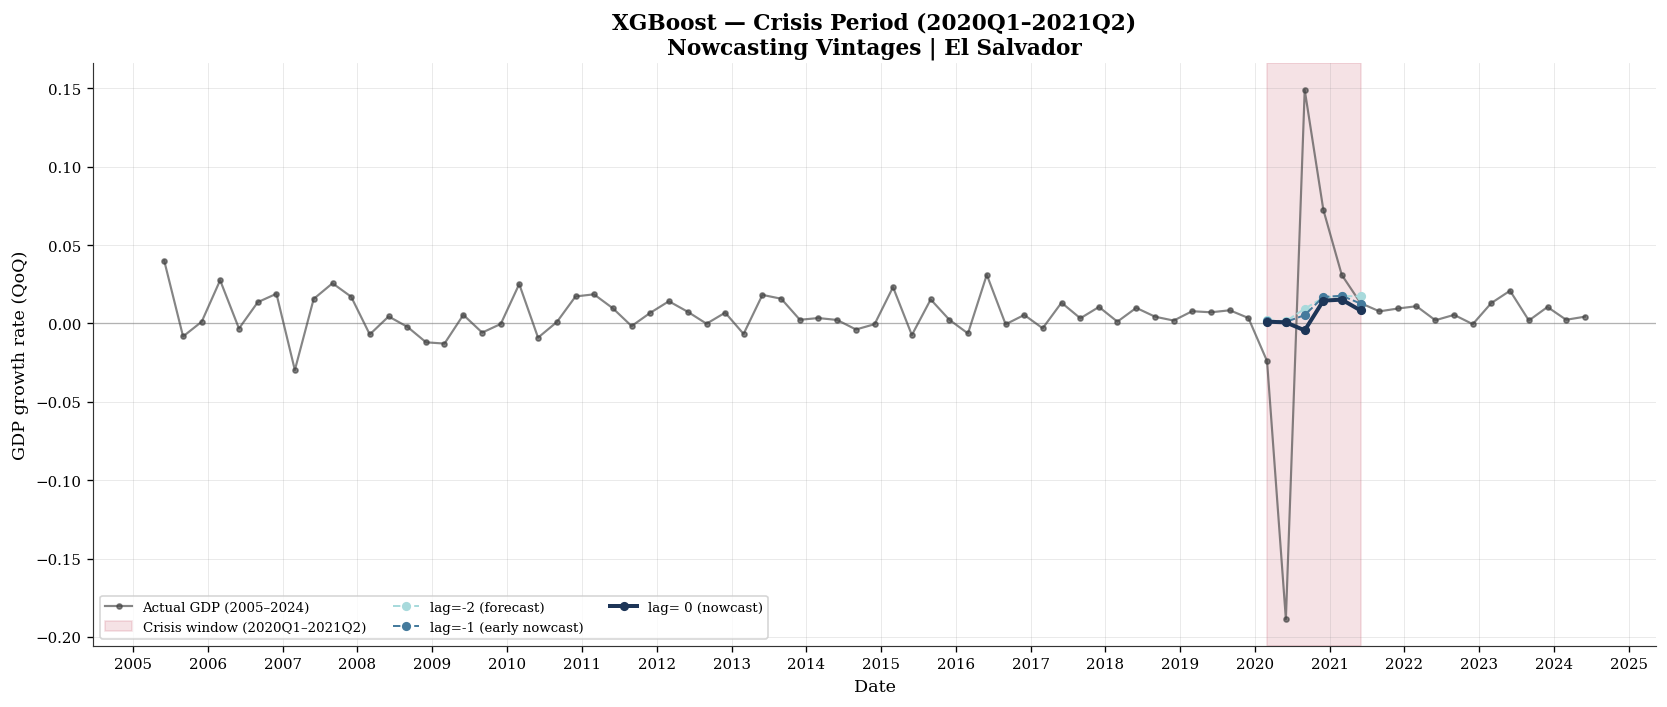

Saved: xgboost_plot_crisis.png


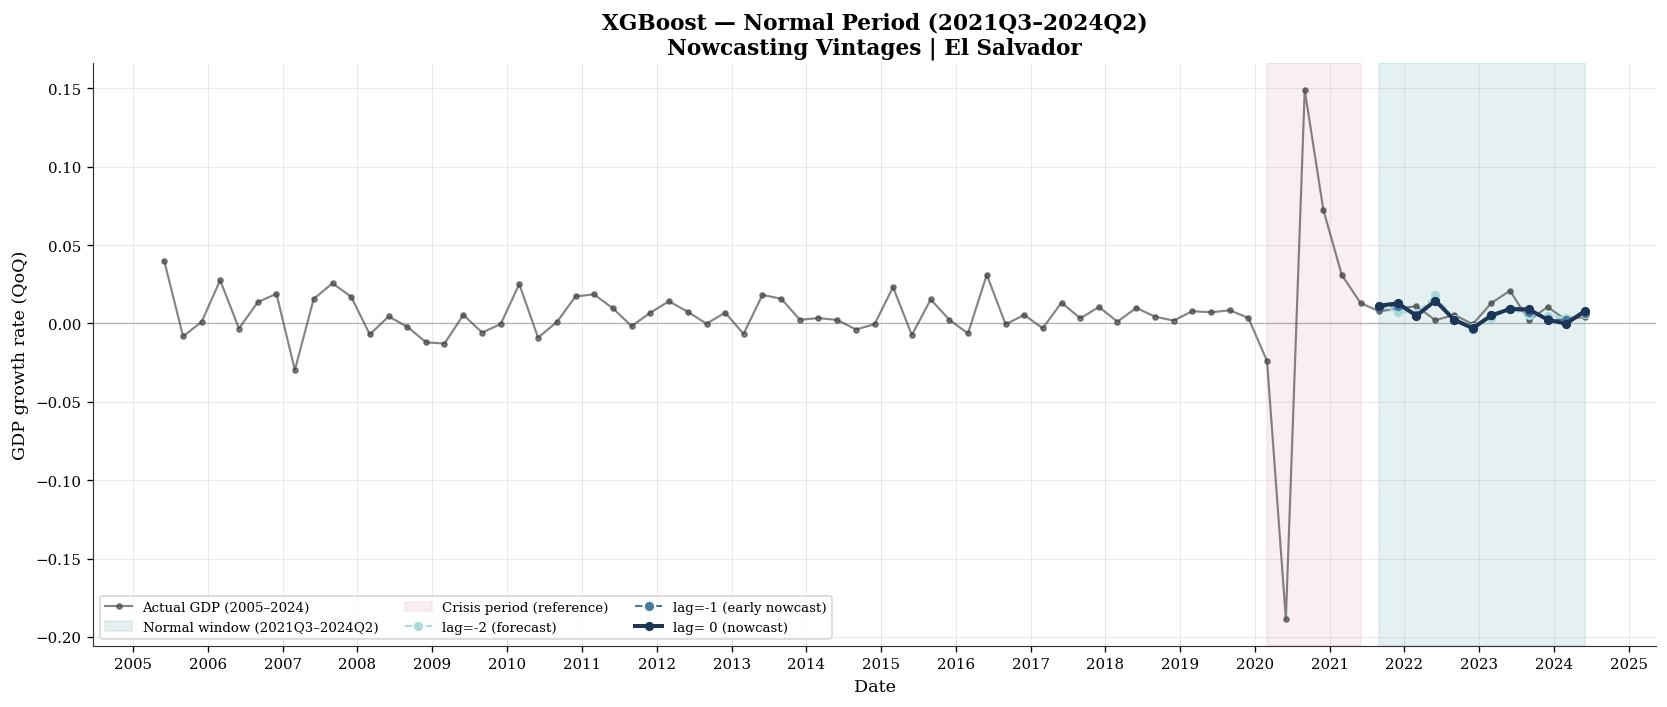

Saved: xgboost_plot_normal.png


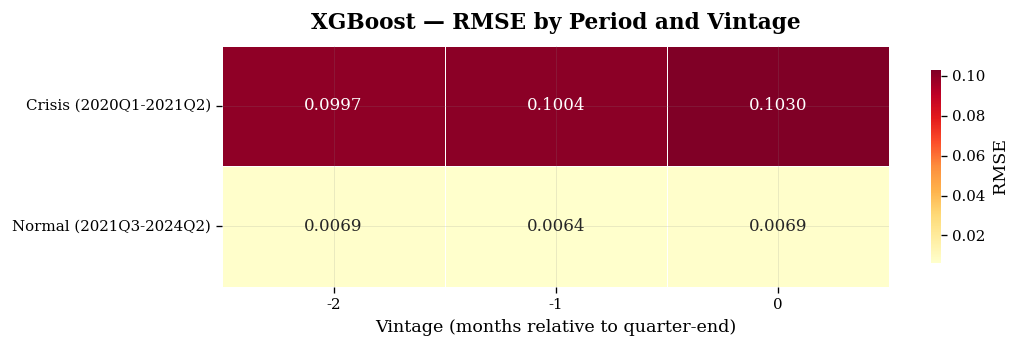

Saved: xgboost_plot_heatmap.png


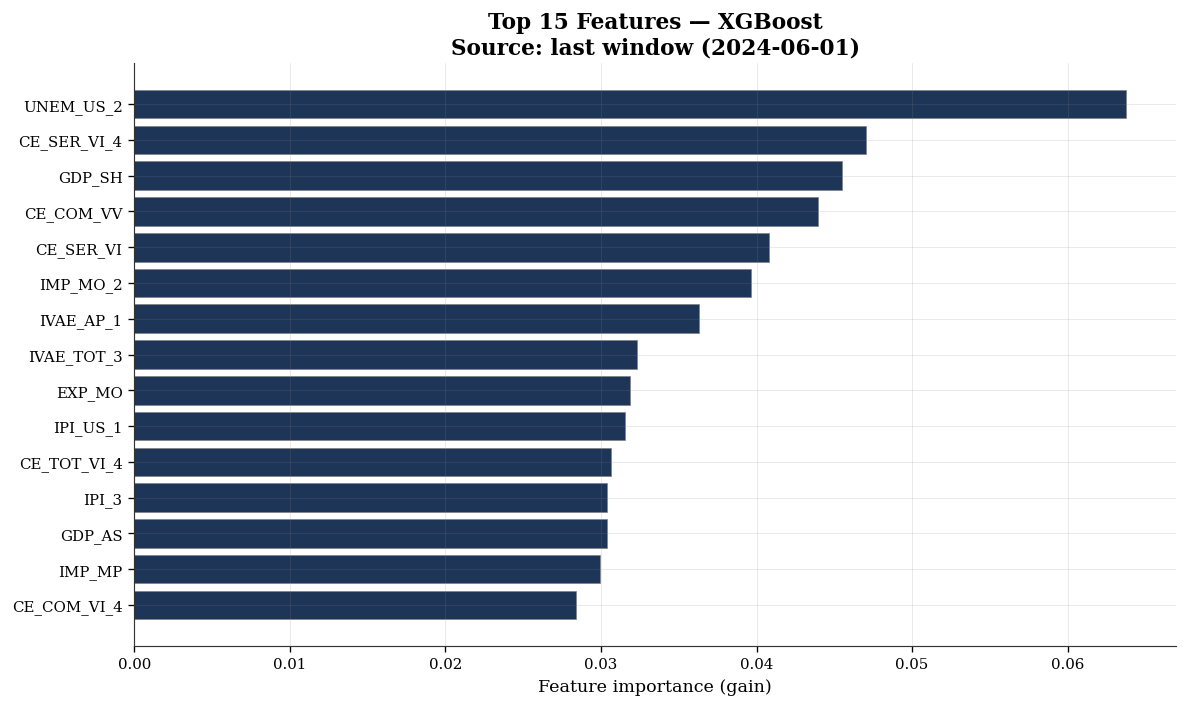

Saved: xgboost_plot_features.png


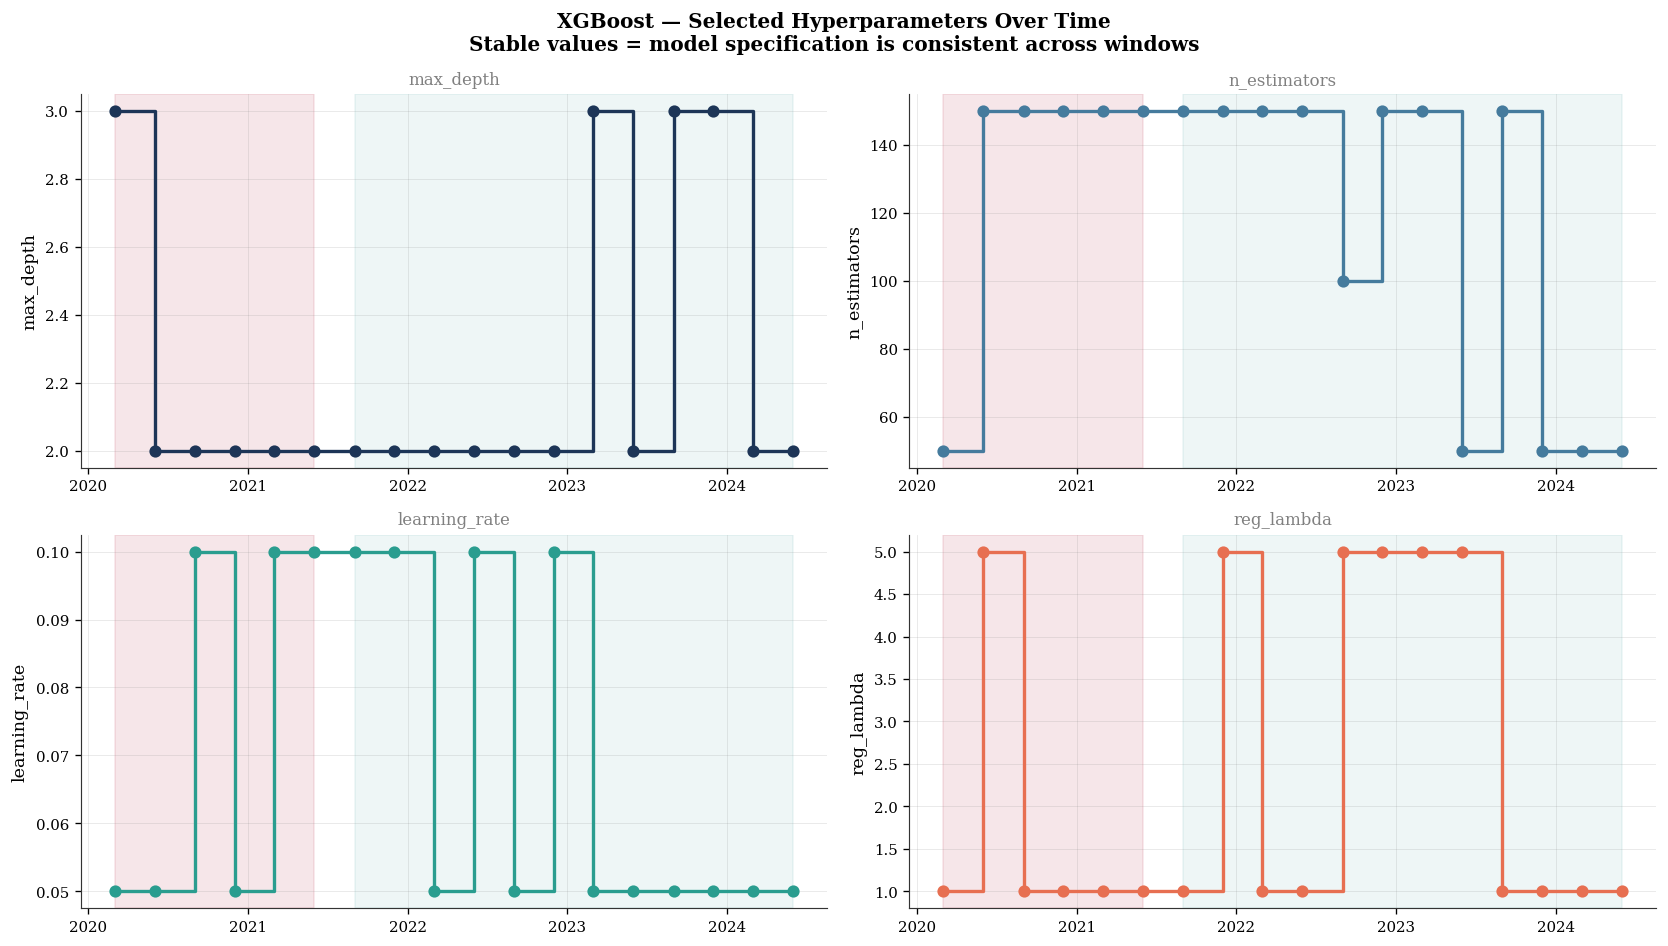

Saved: xgboost_plot_params.png

XGBOOST NOWCASTING COMPLETE
Output : /Users/gabrielaaquino/Desktop/ESA-gdp-nowcasting/Models/results/xgboost


In [2]:
# =============================================================================
# XGBoost.py
# XGBoost nowcasting pipeline for El Salvador GDP.
# Hyperparameters selected via fixed holdout (last 8 quarters of training),
# identical protocol to Ridge and Lasso for direct comparability.
#
# Primary benchmark is ARMA (see ARMA.ipynb). Cross-model comparison is
# done in a separate comparison script that loads all per-model CSVs.
#
# Author : Gabriela Aquino
# =============================================================================
#
# WHY XGBOOST DIFFERS FROM RIDGE AND LASSO
# -----------------------------------------
# XGBoost is a gradient-boosted tree ensemble. Unlike Ridge/Lasso, it:
#   - Captures non-linear relationships and feature interactions
#   - Does NOT require feature scaling (trees are scale-invariant)
#   - Has multiple interacting hyperparameters
#
# NOTE ON MEAN-FILL IMPUTATION (methodological choice):
# XGBoost natively handles NaN via a "default direction" learned per split.
# In principle, passing NaN directly would let XGBoost exploit this.
# HOWEVER, we deliberately mean-fill here to keep the data-processing
# protocol IDENTICAL to Ridge/Lasso. Cross-model comparability is more
# valuable for the thesis than a small potential gain from NaN handling.
# A sensitivity analysis (NaN vs mean-fill) could be added as an appendix.
#
# CRITICAL: with n ~ 55-76 observations and ~615 features, XGBoost is
# strongly constrained by:
#   - Shallow trees (max_depth <= 3)
#   - Moderate n_estimators (50 to 150)
#   - L2 regularisation (reg_lambda >= 1)
#   - No early stopping (would complicate the protocol vs Ridge/Lasso)
# =============================================================================
#
# TUNABLE PARAMETERS (safe to modify — see Section 1):
#   N_LAGS_FEATURES     : monthly lags per predictor (baseline = 4)
#   XGB_PARAM_GRID      : hyperparameter grid
#   N_HOLDOUT_QUARTERS  : size of fixed holdout for tuning (default 8)
#
# SHARED CONFIG (do not modify — comes from nowcast_utils.py):
#   LAGS, TRAIN_START, TEST_START, TEST_END,
#   CRISIS_START/END, NORMAL_START/END, etc.
# =============================================================================

import sys
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

from xgboost import XGBRegressor

# Selective warning filters.
# We WANT to see XGBoost warnings and warnings from gen_lagged_data.
# Silence only noisy FutureWarning and UserWarning from third parties.
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# =============================================================================
# 0. PATHS AND SHARED-CONFIG IMPORT
# =============================================================================
BASE_DIR  = Path.home() / "Desktop" / "ESA-gdp-nowcasting"
DATA_DIR  = BASE_DIR / "Data"
MODEL_DIR = BASE_DIR / "Models"
OUT_DIR   = MODEL_DIR / "results" / "xgboost"
OUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(MODEL_DIR))

from nowcast_utils import (
    LAGS, TARGET_VARIABLE,
    TRAIN_START, TEST_START, TEST_END,
    CRISIS_START, CRISIS_END,
    NORMAL_START, NORMAL_END,
    RANDOM_SEED,
    gen_lagged_data, flatten_data, mean_fill_dataset,
    classify_crisis_periods,
    rmse, mae,
)

PATH_DATA = DATA_DIR / "data_tf.csv"
PATH_META = DATA_DIR / "meta_data_v2.csv"
for p in [PATH_DATA, PATH_META]:
    if not p.exists():
        raise FileNotFoundError(f"\n  File not found: {p}")

# =============================================================================
# 1. TUNABLE PARAMETERS (XGBoost-specific)
# =============================================================================
# Number of monthly lags per predictor. MUST match Ridge and Lasso.
N_LAGS_FEATURES: int = 4

# Fixed holdout: last N quarters of training used for hyperparameter selection.
# MUST match Ridge and Lasso for comparability.
N_HOLDOUT_QUARTERS: int = 8

# XGBoost hyperparameter grid (adelgazado para n pequeño).
# max_depth       : tree depth. 2-3 = shallow (low variance). Do NOT use > 3.
# n_estimators    : number of boosting rounds. Moderate range given n <= 76.
# learning_rate   : step size shrinkage.
# reg_lambda      : L2 regularisation on leaf weights.
# subsample       : fixed at 0.8 (row sampling, small n).
# colsample_bytree: fixed at 0.8 (column sampling, p >> n).
# min_child_weight: fixed at 5 (conservative for small n).
XGB_PARAM_GRID = {
    "max_depth":        [2, 3],
    "n_estimators":     [50, 100, 150],
    "learning_rate":    [0.05, 0.10],
    "reg_lambda":       [1.0, 5.0],
    # Fixed parameters (not in grid, applied to all candidates)
}
XGB_FIXED_PARAMS = {
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "objective":        "reg:squarederror",
    "eval_metric":      "rmse",
    "random_state":     RANDOM_SEED,
    "n_jobs":           -1,
    "verbosity":        0,
}

np.random.seed(RANDOM_SEED)

# =============================================================================
# 2. LOAD DATA
# =============================================================================
print("Loading data...")
data     = pd.read_csv(PATH_DATA, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
metadata = pd.read_csv(PATH_META)

print(f"  Rows       : {data.shape[0]}")
print(f"  Columns    : {data.shape[1]}")
print(f"  Date range : {data['date'].min().date()} to {data['date'].max().date()}")
print(f"  GDP obs    : {data[TARGET_VARIABLE].notna().sum()} quarterly observations")

# Build list of all grid combinations
param_keys   = list(XGB_PARAM_GRID.keys())
param_values = list(XGB_PARAM_GRID.values())
all_combos   = list(itertools.product(*param_values))
print(f"  Param grid : {len(all_combos)} combinations (tunable) "
      f"+ {len(XGB_FIXED_PARAMS) - 5} fixed hyperparameters")

test_dates = pd.date_range(TEST_START, TEST_END, freq="3MS").strftime("%Y-%m-%d").tolist()

# =============================================================================
# 3. ROLLING-ORIGIN EVALUATION
# =============================================================================
print("\nRunning rolling-origin XGBoost evaluation...")
print(f"  Train start     : {TRAIN_START}")
print(f"  Test window     : {TEST_START} to {TEST_END}")
print(f"  Vintages        : {LAGS}")
print(f"  Lag depth       : {N_LAGS_FEATURES} monthly lags per predictor")
print(f"  Param grid      : {len(all_combos)} combinations (exhaustive)")
print(f"  Param selection : fixed holdout ({N_HOLDOUT_QUARTERS} quarters)")
print(f"  Scaling         : not applied (trees are scale-invariant)")
print(f"  Imputation      : training-mean fill (same as Ridge/Lasso)\n")

pred_dict                    = {lag: [] for lag in LAGS}
dates_out                    = []
actuals_out                  = []
best_params_out              = []
feature_importance_by_window = []   # list of (date, df) for post-hoc selection
train_cutoff_last            = None

# For SHAP analysis: keep the model + training matrix of the last
# pre-crisis window. Overwritten at each pre-crisis iteration; after
# the loop completes the variables hold the last valid pre-crisis window.
interp_model   = None
interp_X_train = None
interp_window  = None

for nowcast_date in test_dates:

    # --- Actual GDP value ----------------------------------------------------
    nowcast_dt  = pd.to_datetime(nowcast_date)
    actual_rows = data.loc[
        (data["date"] == nowcast_dt) & (~pd.isna(data[TARGET_VARIABLE])),
        TARGET_VARIABLE
    ]
    if actual_rows.empty:
        print(f"  [{nowcast_date}] No actual GDP - skipping.")
        for lag in LAGS:
            pred_dict[lag].append(np.nan)
        dates_out.append(nowcast_date)
        actuals_out.append(np.nan)
        best_params_out.append(None)
        continue

    dates_out.append(nowcast_date)
    actuals_out.append(float(actual_rows.values[0]))

    # --- Training window -----------------------------------------------------
    train_cutoff      = (nowcast_dt - pd.DateOffset(months=3)).strftime("%Y-%m-%d")
    train_cutoff_last = train_cutoff

    train_raw = data.loc[
        (data["date"] >= TRAIN_START) & (data["date"] <= train_cutoff)
    ].copy()

    n_q = train_raw[TARGET_VARIABLE].notna().sum()

    # --- Build feature matrix ------------------------------------------------
    # Mean-fill with training means (documented methodological choice to
    # preserve protocol identity with Ridge/Lasso, at the cost of XGBoost
    # not exploiting its native NaN handling).
    train_filled = mean_fill_dataset(training=train_raw, test=train_raw)
    train_flat   = flatten_data(train_filled, TARGET_VARIABLE, N_LAGS_FEATURES)
    train_flat   = (
        train_flat
        .loc[train_flat["date"].dt.month.isin([3, 6, 9, 12])]
        .dropna(axis=0, how="any")
        .reset_index(drop=True)
    )

    if len(train_flat) < N_HOLDOUT_QUARTERS + 5:
        print(f"  [{nowcast_date}] Only {len(train_flat)} rows - skipping.")
        for lag in LAGS:
            pred_dict[lag].append(np.nan)
        best_params_out.append(None)
        continue

    X_train = train_flat.drop(columns=["date", TARGET_VARIABLE])
    y_train = train_flat[TARGET_VARIABLE]

    # --- Hyperparameter selection via fixed holdout --------------------------
    # Protocol identical to ridge_final.py and lasso_final.py:
    #   inner-train = all quarters except last N_HOLDOUT_QUARTERS
    #   holdout     = last N_HOLDOUT_QUARTERS of the training window
    #
    # XGBoost does NOT need feature scaling — trees split on rank order,
    # not on absolute distances.
    X_inner = X_train.iloc[:-N_HOLDOUT_QUARTERS]
    y_inner = y_train.iloc[:-N_HOLDOUT_QUARTERS]
    X_hold  = X_train.iloc[-N_HOLDOUT_QUARTERS:]
    y_hold  = y_train.iloc[-N_HOLDOUT_QUARTERS:]

    # Grid search: find combination that minimises holdout RMSE
    best_params, best_rmse = None, np.inf
    for combo in all_combos:
        tunable = dict(zip(param_keys, combo))
        xgb_cv = XGBRegressor(**XGB_FIXED_PARAMS, **tunable)
        xgb_cv.fit(X_inner, y_inner)
        val_rmse = rmse(y_hold, xgb_cv.predict(X_hold))
        if val_rmse < best_rmse:
            best_rmse   = val_rmse
            best_params = tunable

    best_params_out.append(best_params)

    # --- Refit XGBoost on full training with best params --------------------
    final_xgb = XGBRegressor(**XGB_FIXED_PARAMS, **best_params)
    final_xgb.fit(X_train, y_train)

    # Feature importance from this window (gain = loss reduction)
    feature_importance_by_window.append((
        nowcast_date,
        pd.DataFrame({
            "feature":    X_train.columns,
            "importance": final_xgb.feature_importances_,
        }).sort_values("importance", ascending=False)
    ))

    # Keep model object + training matrix of the chosen interpretability
    # window (last pre-crisis). Used by SHAP analysis further below.
    if pd.to_datetime(nowcast_date) < pd.to_datetime(CRISIS_START):
        # Overwrite each pre-crisis window; last one survives.
        interp_model    = final_xgb
        interp_X_train  = X_train.copy()
        interp_window   = nowcast_date

    # --- Diagnostics print ---------------------------------------------------
    print(f"  [{nowcast_date}]  "
          f"depth={best_params['max_depth']}  "
          f"n_est={best_params['n_estimators']}  "
          f"lr={best_params['learning_rate']:.2f}  "
          f"lambda={best_params['reg_lambda']:.1f}  "
          f"n_train={n_q}  features={X_train.shape[1]}")

    # --- Predict for each vintage -------------------------------------------
    for lag in LAGS:
        vintage_data = gen_lagged_data(metadata, data, nowcast_date, lag)
        vintage_data = mean_fill_dataset(training=train_raw, test=vintage_data)
        vintage_flat = flatten_data(vintage_data, TARGET_VARIABLE, N_LAGS_FEATURES)

        target_row = vintage_flat.loc[vintage_flat["date"] == nowcast_dt]
        if target_row.empty:
            pred_dict[lag].append(np.nan)
            continue

        X_test = (
            target_row
            .drop(columns=["date", TARGET_VARIABLE], errors="ignore")
            .reindex(columns=X_train.columns, fill_value=0.0)
        )

        pred_dict[lag].append(float(final_xgb.predict(X_test)[0]))

# =============================================================================
# 4. PERFORMANCE METRICS
# =============================================================================
# Period labels come from nowcast_utils (single source of truth)
period_labels = classify_crisis_periods(dates_out).tolist()

# --- Full test period --------------------------------------------------------
full_rows = []
for lag in LAGS:
    full_rows.append({
        "Vintage": lag,
        "RMSE":    round(rmse(actuals_out, pred_dict[lag]), 6),
        "MAE":     round(mae(actuals_out,  pred_dict[lag]), 6),
        "n":       sum(1 for v in pred_dict[lag] if not np.isnan(v)),
    })
perf_full = pd.DataFrame(full_rows)

# --- Stratified: Crisis / Normal --------------------------------------------
strat_rows = []
for period, label in [
    ("crisis", "Crisis (2020Q1-2021Q2)"),
    ("normal", "Normal (2021Q3-2024Q2)"),
]:
    idx = [i for i, p in enumerate(period_labels) if p == period]
    y   = [actuals_out[i] for i in idx]
    for lag in LAGS:
        yhat = [pred_dict[lag][i] for i in idx]
        strat_rows.append({
            "Period":  label,
            "Vintage": lag,
            "n":       len([v for v in yhat if not np.isnan(v)]),
            "RMSE":    round(rmse(y, yhat), 6),
            "MAE":     round(mae(y,  yhat), 6),
        })
perf_strat = pd.DataFrame(strat_rows)

# --- Print results -----------------------------------------------------------
print("\n" + "=" * 64)
print("FULL TEST PERIOD — XGBoost")
print("=" * 64)
print(perf_full.to_string(index=False))

print("\n" + "=" * 64)
print("STRATIFIED — Crisis vs Normal")
print("=" * 64)
print(perf_strat.to_string(index=False))

print(f"\nBenchmark: compare against ARMA (see arma_benchmark.csv).")
print(f"Cross-model comparison is done in the dedicated comparison script.")

# =============================================================================
# 5. SAVE CSVs
# =============================================================================
# Save ALL tunable hyperparameters (not just 4 of them).
pred_table = pd.DataFrame({
    "date":        dates_out,
    "actual":      actuals_out,
    **{f"lag_{'-' if lag < 0 else '+'}{abs(lag)}": pred_dict[lag] for lag in LAGS},
    "period_type": period_labels,
})
for pk in param_keys:
    pred_table[f"best_{pk}"] = [p[pk] if p else None for p in best_params_out]

pred_table.to_csv(OUT_DIR   / "xgboost_predictions.csv",            index=False)
perf_full.to_csv(OUT_DIR    / "xgboost_performance_full.csv",       index=False)
perf_strat.to_csv(OUT_DIR   / "xgboost_performance_stratified.csv", index=False)

# --- Feature importance: last pre-crisis window -----------------------------
# Same logic as Ridge/Lasso: avoid COVID-period coefficient instability
# by showing a window where tree splits reflect typical economic relations.
crisis_start_dt = pd.to_datetime(CRISIS_START)
pre_crisis = [
    (d, df) for (d, df) in feature_importance_by_window
    if pd.to_datetime(d) < crisis_start_dt
]

if pre_crisis:
    chosen_date, chosen_df = pre_crisis[-1]
    feature_importance_source = f"last pre-crisis window ({chosen_date})"
elif feature_importance_by_window:
    chosen_date, chosen_df = feature_importance_by_window[-1]
    feature_importance_source = f"last window ({chosen_date})"
else:
    chosen_df = None
    feature_importance_source = "no window available"

if chosen_df is not None:
    chosen_df.to_csv(OUT_DIR / "xgboost_feature_importance.csv", index=False)
    print(f"\nFeature importance from: {feature_importance_source}")

# =============================================================================
# 5b. SHAP ANALYSIS (on the last pre-crisis window)
# =============================================================================
# SHAP provides directional (signed) feature importance and interactions,
# whereas feature_importances_ only ranks features by aggregate gain.
# We run SHAP on the model of the last pre-crisis window — the same model
# used for feature_importance_ above — to keep the two outputs consistent.
#
# Requires: pip install shap
# If shap is not installed, this block is skipped and a warning is printed;
# the rest of the pipeline is unaffected.

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("\n[SHAP] shap not installed. Skipping SHAP analysis.")
    print("[SHAP] To enable: pip install shap")

if SHAP_AVAILABLE and interp_model is not None:
    print(f"\nRunning SHAP analysis on pre-crisis window ({interp_window})...")
    explainer  = shap.TreeExplainer(interp_model)
    shap_vals  = explainer.shap_values(interp_X_train)

    # Mean |SHAP| per feature (aggregate importance)
    shap_mean_abs = pd.DataFrame({
        "feature":       interp_X_train.columns,
        "mean_abs_shap": np.abs(shap_vals).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    shap_mean_abs.to_csv(OUT_DIR / "xgboost_shap_importance.csv", index=False)
    print(f"  Saved: xgboost_shap_importance.csv  (source window: {interp_window})")

    # Bar plot: top 20 mean |SHAP|
    top_s = shap_mean_abs.head(20)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top_s["feature"][::-1], top_s["mean_abs_shap"][::-1],
            color="#e07b00", edgecolor="gray", linewidth=0.4)
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(f"XGBoost — SHAP Feature Importance (top 20)\n"
                 f"Source: last pre-crisis window ({interp_window})",
                 fontweight="bold")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "xgboost_shap_bar.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved: xgboost_shap_bar.png")

    # Bee-swarm plot: shows distribution of SHAP values per feature
    # with colour indicating feature value (blue=low, red=high). Very
    # informative for showing direction of effect.
    top_features = shap_mean_abs.head(20)["feature"].tolist()
    top_idx      = [list(interp_X_train.columns).index(f) for f in top_features]
    X_top        = interp_X_train[top_features]

    fig = plt.figure(figsize=(10, 9))
    shap.summary_plot(
        shap_vals[:, top_idx], X_top,
        feature_names=top_features,
        plot_type="dot", show=False, max_display=20, alpha=0.7
    )
    plt.title(f"XGBoost — SHAP Summary (top 20) | {interp_window}\n"
              "Colour = feature value (blue=low, red=high); "
              "x-axis = SHAP impact on prediction",
              fontweight="bold", pad=15)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "xgboost_shap_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved: xgboost_shap_beeswarm.png")

elif SHAP_AVAILABLE and interp_model is None:
    print("\n[SHAP] No pre-crisis window was successfully fitted; "
          "SHAP analysis skipped.")

print(f"\nCSVs saved to: {OUT_DIR}")

# =============================================================================
# 6. PLOTTING STYLE (matches ARMA/Lasso/Ridge for visual consistency)
# =============================================================================
STYLE = {
    "c_crisis":         "#B6213B",
    "c_normal":         "#2A8F93",
    "c_actual":         "#2E2E2E",
    "zero_line_colour": "#555555",
    "shade_crisis":     0.11,
    "shade_normal":     0.08,
}
plt.rcParams.update({
    "font.family":       "serif",
    "axes.titlesize":    13,
    "axes.labelsize":    10.5,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "axes.grid":         True,
    "grid.alpha":        0.20,
    "grid.color":        "#888888",
    "grid.linewidth":    0.5,
    "axes.edgecolor":    "#333333",
    "axes.linewidth":    0.7,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        120,
})

LAG_COLORS = {-2: "#a8dadc", -1: "#457b9d", 0: "#1d3557"}
LAG_LW     = {-2: 1.2, -1: 1.2, 0: 2.4}
LAG_LS     = {-2: "--", -1: "--", 0: "-"}
LAG_LABELS = {-2: "lag=-2 (forecast)",
              -1: "lag=-1 (early nowcast)",
               0: "lag= 0 (nowcast)"}


def _format_xaxis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))


def _shade_regimes(ax):
    ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
               alpha=STYLE["shade_crisis"], color=STYLE["c_crisis"],
               edgecolor="none", zorder=0)
    ax.axvspan(pd.to_datetime(NORMAL_START), pd.to_datetime(NORMAL_END),
               alpha=STYLE["shade_normal"], color=STYLE["c_normal"],
               edgecolor="none", zorder=0)


full_series = (
    data[["date", TARGET_VARIABLE]]
    .dropna(subset=[TARGET_VARIABLE])
    .sort_values("date")
    .reset_index(drop=True)
)

# =============================================================================
# 7. PLOT A — Crisis period (2020Q1–2021Q2)
# =============================================================================
crisis_rows = pred_table[pred_table["period_type"] == "crisis"].copy()
crisis_rows["date"] = pd.to_datetime(crisis_rows["date"])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(full_series["date"], full_series[TARGET_VARIABLE],
        color="#444444", lw=1.3, marker="o", ms=3, alpha=0.65,
        label="Actual GDP (2005–2024)", zorder=3)
ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
           alpha=0.13, color=STYLE["c_crisis"], zorder=0,
           label="Crisis window (2020Q1–2021Q2)")
ax.axhline(0, color=STYLE["zero_line_colour"], lw=0.8, alpha=0.4, zorder=1)

for lag in LAGS:
    col = f"lag_{'-' if lag < 0 else '+'}{abs(lag)}"
    ax.plot(crisis_rows["date"], crisis_rows[col],
            color=LAG_COLORS[lag], lw=LAG_LW[lag], ls=LAG_LS[lag],
            marker="o", ms=4.5, label=LAG_LABELS[lag], zorder=5)

ax.set_xlabel("Date")
ax.set_ylabel("GDP growth rate (QoQ)")
ax.set_title("XGBoost — Crisis Period (2020Q1–2021Q2)\n"
             "Nowcasting Vintages | El Salvador",
             fontweight="bold")
ax.legend(fontsize=8, ncol=3, loc="lower left")
_format_xaxis(ax)
plt.tight_layout()
fig.savefig(OUT_DIR / "xgboost_plot_crisis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xgboost_plot_crisis.png")

# =============================================================================
# 8. PLOT B — Normal period (2021Q3–2024Q2)
# =============================================================================
normal_rows = pred_table[pred_table["period_type"] == "normal"].copy()
normal_rows["date"] = pd.to_datetime(normal_rows["date"])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(full_series["date"], full_series[TARGET_VARIABLE],
        color="#444444", lw=1.3, marker="o", ms=3, alpha=0.65,
        label="Actual GDP (2005–2024)", zorder=3)
ax.axvspan(pd.to_datetime(NORMAL_START), pd.to_datetime(NORMAL_END),
           alpha=0.12, color=STYLE["c_normal"], zorder=0,
           label="Normal window (2021Q3–2024Q2)")
ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
           alpha=0.07, color=STYLE["c_crisis"], zorder=0,
           label="Crisis period (reference)")
ax.axhline(0, color=STYLE["zero_line_colour"], lw=0.8, alpha=0.4, zorder=1)

for lag in LAGS:
    col = f"lag_{'-' if lag < 0 else '+'}{abs(lag)}"
    ax.plot(normal_rows["date"], normal_rows[col],
            color=LAG_COLORS[lag], lw=LAG_LW[lag], ls=LAG_LS[lag],
            marker="o", ms=4.5, label=LAG_LABELS[lag], zorder=5)

ax.set_xlabel("Date")
ax.set_ylabel("GDP growth rate (QoQ)")
ax.set_title("XGBoost — Normal Period (2021Q3–2024Q2)\n"
             "Nowcasting Vintages | El Salvador",
             fontweight="bold")
ax.legend(fontsize=8, ncol=3, loc="lower left")
_format_xaxis(ax)
plt.tight_layout()
fig.savefig(OUT_DIR / "xgboost_plot_normal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xgboost_plot_normal.png")

# =============================================================================
# 9. PLOT C — RMSE heatmap
# =============================================================================
pivot = perf_strat.pivot(index="Period", columns="Vintage", values="RMSE")
fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.6, ax=ax, cbar_kws={"label": "RMSE", "shrink": 0.8})
ax.set_title("XGBoost — RMSE by Period and Vintage",
             fontweight="bold", pad=10)
ax.set_xlabel("Vintage (months relative to quarter-end)")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(OUT_DIR / "xgboost_plot_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xgboost_plot_heatmap.png")

# =============================================================================
# 10. PLOT D — Feature importance (top 15)
# =============================================================================
if chosen_df is not None:
    top_n     = 15
    top_feats = chosen_df.head(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_feats["feature"][::-1],
            top_feats["importance"][::-1],
            color="#1d3557", edgecolor="gray", linewidth=0.4)
    ax.set_xlabel("Feature importance (gain)")
    ax.set_title(f"Top {top_n} Features — XGBoost\n"
                 f"Source: {feature_importance_source}",
                 fontweight="bold")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "xgboost_plot_features.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: xgboost_plot_features.png")

# =============================================================================
# 11. PLOT E — Selected hyperparameters over time
# =============================================================================
valid = [(d, p) for d, p in zip(dates_out, best_params_out) if p is not None]
if valid:
    v_dates  = pd.to_datetime([x[0] for x in valid])
    v_params = [x[1] for x in valid]

    param_plot = param_keys
    n_params   = len(param_plot)
    n_cols     = 2
    n_rows     = (n_params + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(14, 4 * n_rows), squeeze=False)
    fig.suptitle("XGBoost — Selected Hyperparameters Over Time\n"
                 "Stable values = model specification is consistent across windows",
                 fontweight="bold")

    colors = ["#1d3557", "#457b9d", "#2a9d8f", "#e76f51", "#f4a261", "#b5838d"]
    for idx, (param, color) in enumerate(zip(param_plot, colors)):
        ax   = axes[idx // n_cols][idx % n_cols]
        _shade_regimes(ax)
        vals = [p[param] for p in v_params]
        ax.step(v_dates, vals, color=color, lw=2, where="post")
        ax.scatter(v_dates, vals, color=color, s=40, zorder=5)
        ax.set_title(param, fontsize=10, color="gray")
        ax.set_ylabel(param)
        _format_xaxis(ax)

    # Hide any unused axes (if n_params doesn't fill the grid)
    for idx in range(n_params, n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].set_visible(False)

    plt.tight_layout()
    fig.savefig(OUT_DIR / "xgboost_plot_params.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: xgboost_plot_params.png")

# =============================================================================
# DONE
# =============================================================================
print("\n" + "=" * 64)
print("XGBOOST NOWCASTING COMPLETE")
print("=" * 64)
print(f"Output : {OUT_DIR}")